# This notebook demonstrates the use of Multi-region Sparse Component Analysis (mSCA) using a cycling dataset

* Data are trial-averaged firing rates of individual neurons collected from motor cortex (primary motor and dorsal premotor) of a non-human primate.

* The monkey was performing a cycling task ([Russo et al., 2018](https://pubmed.ncbi.nlm.nih.gov/29398358/))

* Briefly, this task involves the monkey using a bicycle pedal to traverse a virtual environment.

* On each trial, the monkey is told how many cycles he will have to perform (0.5, 1,2,4, or 7).

* After a variable delay period, the monkey receives a go cue, and he pedals to the target, comes to a stop, and is given a juice reward.

* Single-trial rates have been (lightly) stretched or compressed such that each individual cycle is the same duration.

In [39]:
import matplotlib.pyplot as plt
from msca import *
import os
import importlib
import msca
import msca.models
import msca.architectures
import msca.utils
import msca.simulations
# Suppress MallocStackLogging warnings on macOS
os.environ["MallocStackLogging"] = "0"

# Reload msca and key submodules after code changes
importlib.reload(msca.architectures)
importlib.reload(msca.models)
importlib.reload(msca.utils)
importlib.reload(msca)
importlib.reload(msca.simulations)


# Re-import updated symbols
from msca import *

In [40]:
msca = mSCA(n_components=40, n_epochs=10000, loss_func="Gaussian", lr=1e-3, filter_len=21, linear=False, region_weights=None, lam_sparse=None, lam_orthog=None, lam_region=None, batch_size=64, cd_rate=0.5, decoder_type="nonlinear", decoder_hidden_size=40, decoder_activation="GeLU", device="cpu", cd_mode="both", post_hoc_epoch=1000)

In [41]:
import importlib
import os
import numpy as np
from scipy import io


def load_data(dir_path, f):
    # Load in matlab file
    mat_file = io.loadmat(dir_path + f)

    # Grab data and mask
    data_array = mat_file["data"]
    mask = mat_file["mask"]

    # Grab the start and end indices for each trial
    start_idxs = mat_file["mask"]["firstTimeEachCond"][0][0].squeeze() - 1
    end_idxs = mat_file["mask"]["lastTimeEachCond"][0][0].squeeze()

    return data_array, mask, start_idxs, end_idxs


# Preprocess the loaded data and split into trials
def preprocess(data_array, start_idxs, end_idxs, downsample_factor=5):
    """
    Pre-processing done by Andrew Zimnik
    """
    # Downsample the data
    if downsample_factor is not None:
        data_downsamp = data_array[::downsample_factor]

        # Adjust the start and end indices to account for the downsampling
        start_idxs = start_idxs // downsample_factor
        end_idxs = end_idxs // downsample_factor
    else:
        data_downsamp = data_array

    # Transpose the data to N x TC
    data_concat = data_downsamp.T

    # fr range (for normalizing later)
    fr_range = np.ptp(data_concat, axis=1)[:, None]

    # Soft normalize (divide each neuron by its range + 5)
    data_norm = data_concat / (fr_range + 5)

    # mean-center each neuron
    data_snm_norm = data_norm - np.mean(data_norm, axis=1)[:, None]

    # rename the data for convenience
    # Note that model requires (T x N) input rather than (N x T), which is why there are transposes below
    fit_data = np.copy(data_snm_norm.T)

    # Split the data into trials
    split_data = [fit_data[i:j] for i, j in zip(start_idxs, end_idxs)]

    return split_data




fp = "./data/"
m1_data, m1_mask, m1_start_idxs, m1_end_idxs = load_data(
    f"{fp}", "Drake_interp_cycling_m1_rawRates.mat"
)
sma_data, sma_mask, sma_start_idxs, sma_end_idxs = load_data(
    f"{fp}", "Drake_interp_cycling_sma_rawRates.mat"
)

# Preprocess the data
m1_preprocessed = preprocess(
    m1_data, m1_start_idxs, m1_end_idxs, downsample_factor=5
)
sma_preprocessed = preprocess(
    sma_data, sma_start_idxs, sma_end_idxs, downsample_factor=5
)

# Put data into dictionary format
X = {"M1": m1_preprocessed, "SMA": sma_preprocessed}


In [ ]:
msca.load("./results/msca_cycling_NonlinearEncoder.pt", X)

Using region-weights = {'M1': 0.8285914749426891, 'SMA': 1.2608231468683218}
Using lam_sparse = 0.031020160209899346
Using lam_orthog = 23.021100351856102
Using lam_region = 0.0


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:315: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.output_layer.weight = torch.tensor(V_combined, dtype=torch.float32)  # type: ignore


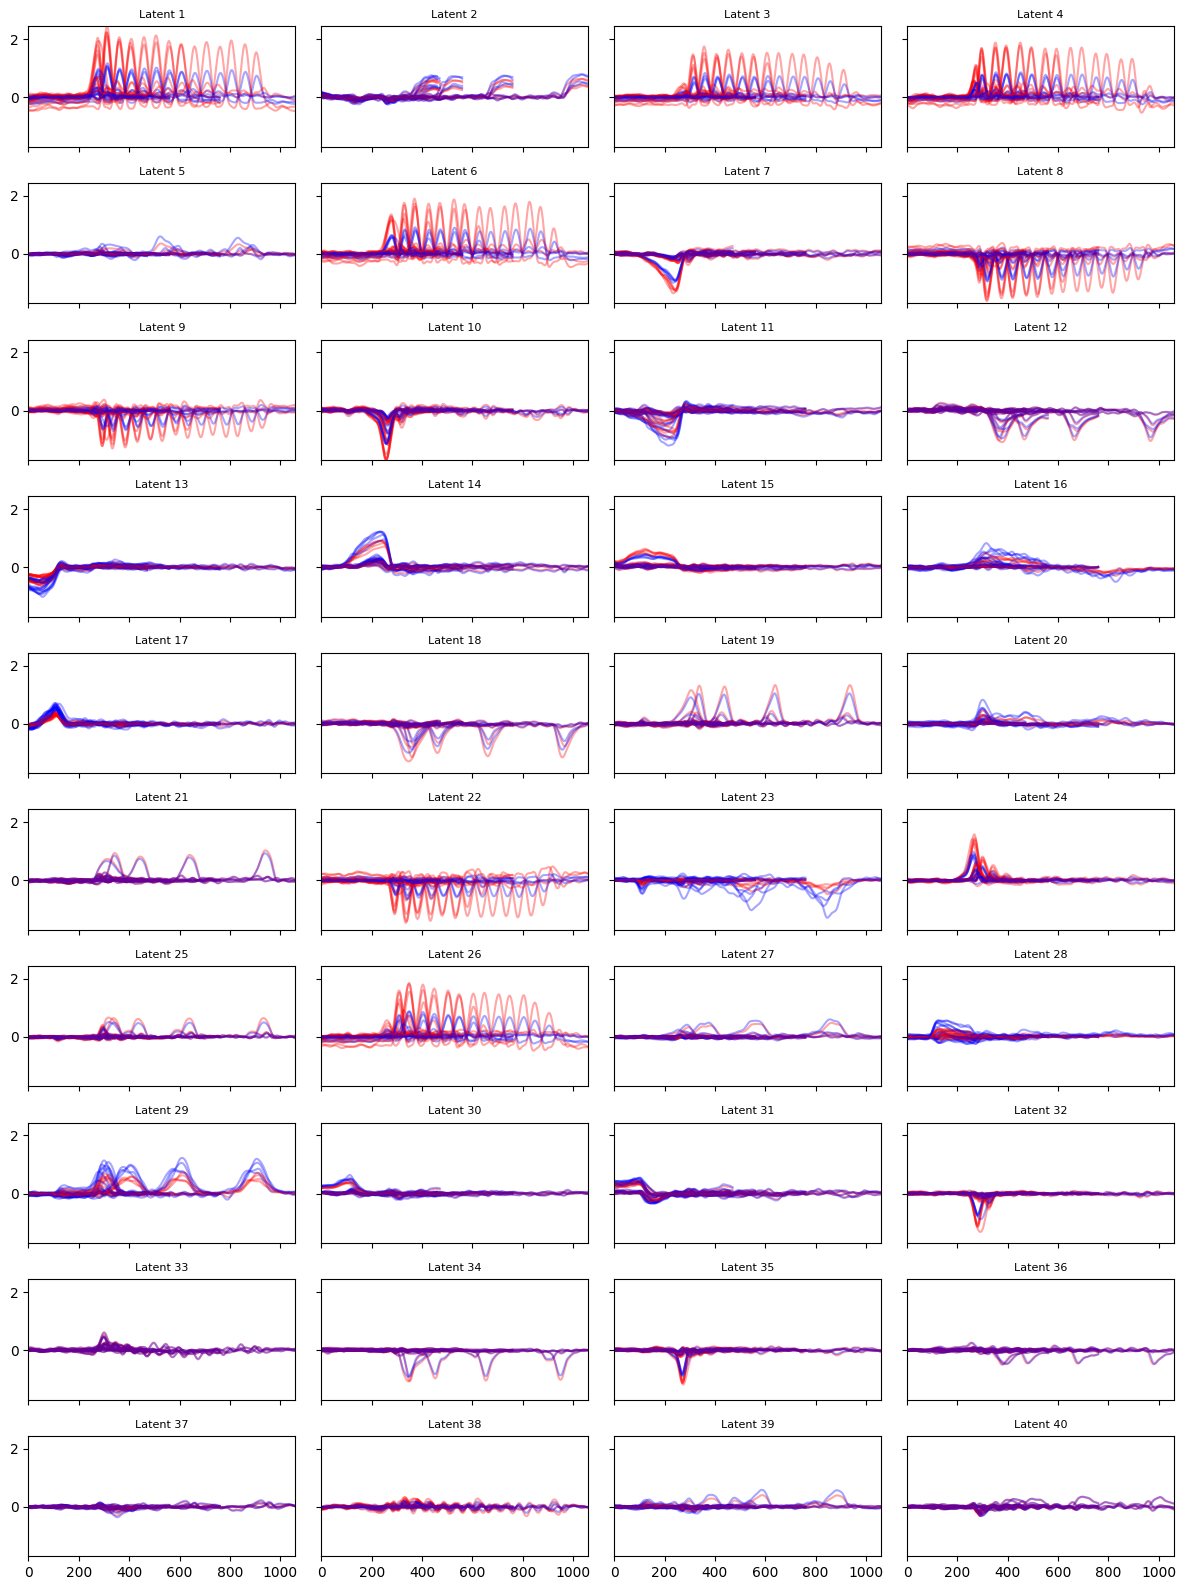

In [27]:
import torch
import torch._dynamo
import numpy as np
import matplotlib.pyplot as plt

torch._dynamo.config.suppress_errors = True

Z = msca.transform(X)

n_components = 40
n_trials = min(20, len(Z['M1']), len(Z['SMA']))

# Global y-range across all plotted traces so every subplot uses the same scale
all_vals = []
for j in range(n_trials):
    all_vals.append(Z['M1'][j][:, :n_components].ravel())
    all_vals.append(Z['SMA'][j][:, :n_components].ravel())
all_vals = np.concatenate(all_vals)
ymin, ymax = np.min(all_vals), np.max(all_vals)

# Global x-range across all plotted traces
max_t = max(max(Z['M1'][j].shape[0], Z['SMA'][j].shape[0]) for j in range(n_trials))

fig, axs = plt.subplots(10, 4, figsize=(12, 16), sharex=True, sharey=True)
for i in range(n_components):
    ax = axs[i // 4, i % 4]
    for j in range(n_trials):
        ax.plot(Z['M1'][j][:, i], c='r', alpha=0.35)
        ax.plot(Z['SMA'][j][:, i], c='b', alpha=0.35)
    ax.set_xlim(0, max_t - 1)
    ax.set_ylim(ymin, ymax)
    ax.set_title(f'Latent {i + 1}', fontsize=8)

plt.tight_layout()
plt.show()

# lam_sparse=2.5

Using region-weights = {'M1': 0.8285914749426891, 'SMA': 1.2608231468683218}
Using lam_sparse = 0.031020160209899346
Using lam_orthog = 23.021100351856102
Using lam_region = 0.0


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:315: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.output_layer.weight = torch.tensor(V_combined, dtype=torch.float32)  # type: ignore


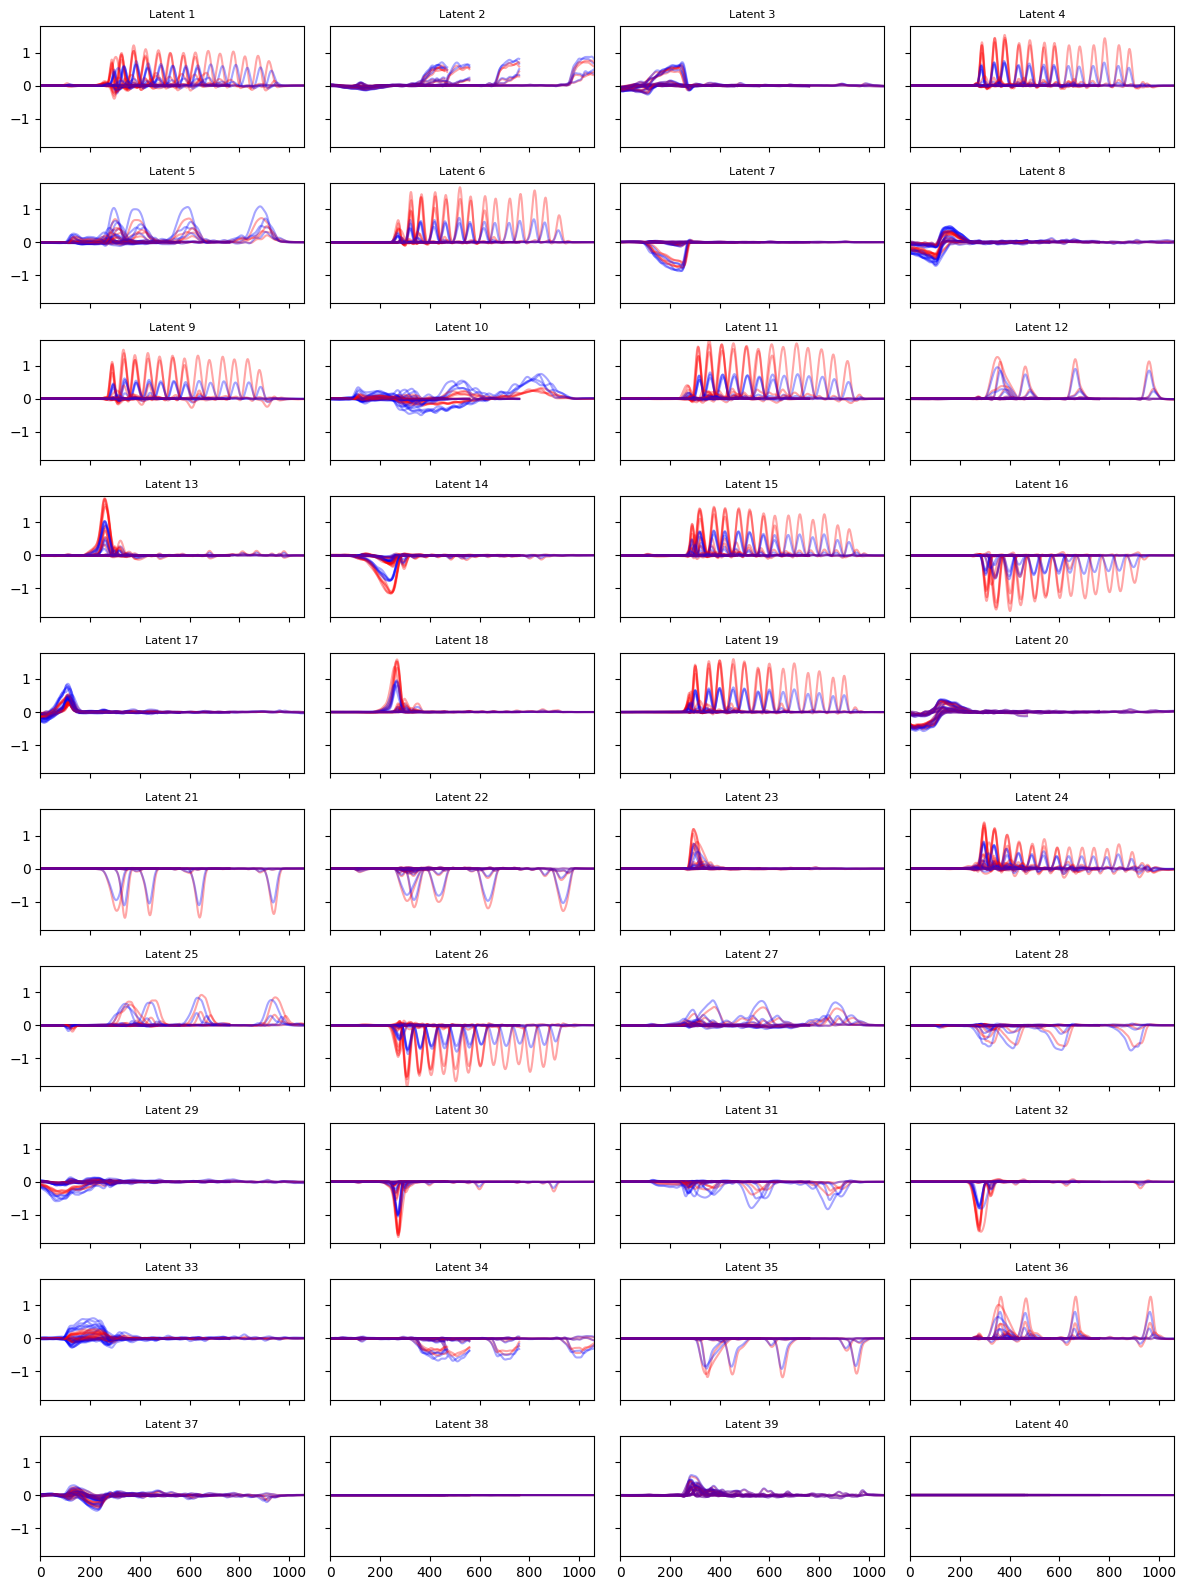

In [ ]:
msca = mSCA(n_components=40, n_epochs=10000, loss_func="Gaussian", lr=1e-3, filter_len=21, linear=False, region_weights=None, lam_sparse=None, lam_orthog=None, lam_region=None, batch_size=64, cd_rate=0.5, decoder_type="nonlinear", decoder_hidden_size=40, decoder_activation="GeLU", device="cpu", cd_mode="both", post_hoc_epoch=1000)
msca.load("./results/msca_cycling_NonlinearEncoder_Sparse2p5.pt", X)
Z = msca.transform(X)

n_components = 40
n_trials = min(20, len(Z['M1']), len(Z['SMA']))

# Global y-range across all plotted traces so every subplot uses the same scale
all_vals = []
for j in range(n_trials):
    all_vals.append(Z['M1'][j][:, :n_components].ravel())
    all_vals.append(Z['SMA'][j][:, :n_components].ravel())
all_vals = np.concatenate(all_vals)
ymin, ymax = np.min(all_vals), np.max(all_vals)

# Global x-range across all plotted traces
max_t = max(max(Z['M1'][j].shape[0], Z['SMA'][j].shape[0]) for j in range(n_trials))

fig, axs = plt.subplots(10, 4, figsize=(12, 16), sharex=True, sharey=True)
for i in range(n_components):
    ax = axs[i // 4, i % 4]
    for j in range(n_trials):
        ax.plot(Z['M1'][j][:, i], c='r', alpha=0.35)
        ax.plot(Z['SMA'][j][:, i], c='b', alpha=0.35)
    ax.set_xlim(0, max_t - 1)
    ax.set_ylim(ymin, ymax)
    ax.set_title(f'Latent {i + 1}', fontsize=8)

plt.tight_layout()
plt.show()

# Loss

Using region-weights = {'M1': 0.8285914749426891, 'SMA': 1.2608231468683218}
Using lam_sparse = 0.031020160209899346
Using lam_orthog = 23.021100351856102
Using lam_region = 0.0


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:315: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.output_layer.weight = torch.tensor(V_combined, dtype=torch.float32)  # type: ignore


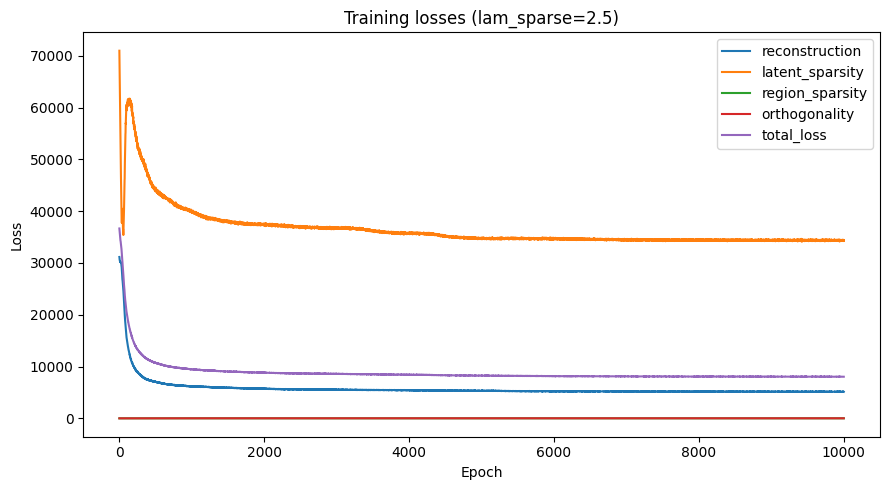

Text(0.5, 0, 'training epoch')

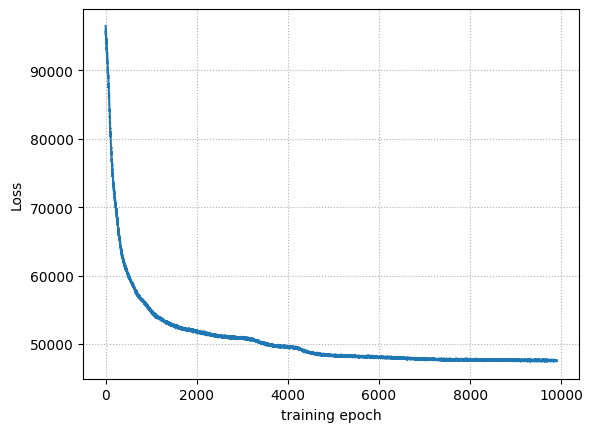

In [33]:

msca = mSCA(n_components=40, n_epochs=10000, loss_func="Gaussian", lr=1e-3, filter_len=21, linear=False, region_weights=None, lam_sparse=None, lam_orthog=None, lam_region=None, batch_size=64, cd_rate=0.5, decoder_type="nonlinear", decoder_hidden_size=40, decoder_activation="GeLU", device="cpu", cd_mode="both", post_hoc_epoch=1000)

model_fp = "./results/msca_cycling_NonlinearEncoder_Sparse2p5.pt"
loss_fp = "./results/losses_NonlinearEncoder_Sparse2p5.npz"

msca.load(model_fp, X)
losses = mSCA.load_losses(loss_fp)

plt.figure(figsize=(9, 5))
for name, vals in losses.items():
    plt.plot(vals, label=name)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training losses (lam_sparse=2.5)")
plt.legend()
plt.tight_layout()
plt.show()


# Concatenate and sum the losses (reconstruction, latent sparsity, region, sparsity, and orthogonality)
loss = np.stack([v for v in losses.values()], axis=1).sum(axis=1)
plt.plot(loss[100:]); # Avoiding weirdness in early training
plt.grid(ls=":");
plt.ylabel("Loss");
plt.xlabel("training epoch")

# Comparison 

## Nonlinear

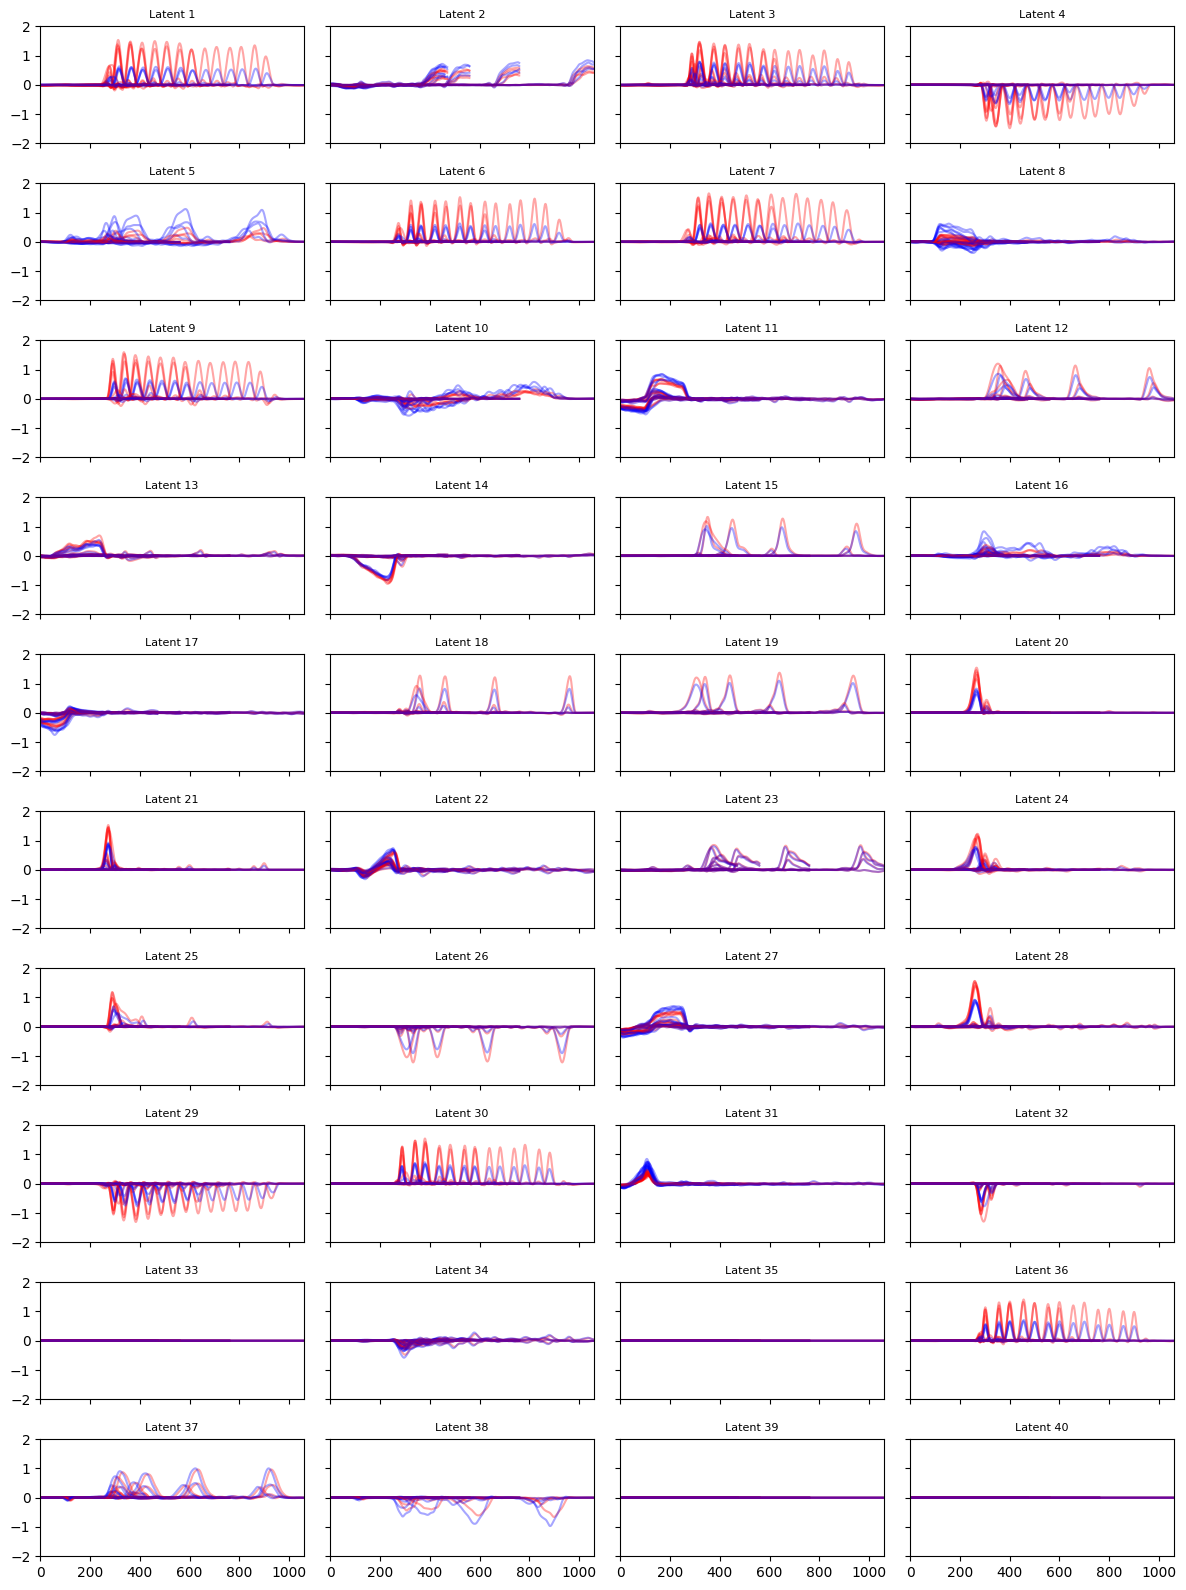

In [34]:
Z = msca.transform(X)
# fig, axs = plt.subplots(10, 4, figsize=(12, 8))
# for trial_num in range(4):
#     Z_m1_i = Z['M1'][trial_num]
#     Z_sma_i = Z['SMA'][trial_num]
#     for i in range(40):
#         axs[i // 4, i % 4].plot(Z_sma_i[:, i], c='b', alpha=0.5)
#         axs[i // 4, i % 4].plot(Z_m1_i[:, i], c='r', alpha=0.5)


n_components = 40
n_trials = min(20, len(Z['M1']), len(Z['SMA']))

# Global y-range across all plotted traces so every subplot uses the same scale
all_vals = []
for j in range(n_trials):
    all_vals.append(Z['M1'][j][:, :n_components].ravel())
    all_vals.append(Z['SMA'][j][:, :n_components].ravel())
all_vals = np.concatenate(all_vals)
ymin, ymax = np.min(all_vals), np.max(all_vals)
ymin, ymax = -2,2

# Global x-range across all plotted traces
max_t = max(max(Z['M1'][j].shape[0], Z['SMA'][j].shape[0]) for j in range(n_trials))

fig, axs = plt.subplots(10, 4, figsize=(12, 16), sharex=True, sharey=True)
for i in range(n_components):
    ax = axs[i // 4, i % 4]
    for j in range(n_trials):
        ax.plot(Z['M1'][j][:, i], c='r', alpha=0.35)
        ax.plot(Z['SMA'][j][:, i], c='b', alpha=0.35)
    ax.set_xlim(0, max_t - 1)
    ax.set_ylim(ymin, ymax)
    ax.set_title(f'Latent {i + 1}', fontsize=8)

plt.tight_layout()
plt.show()

# Linear

Using region-weights = {'M1': 0.8285914749426891, 'SMA': 1.2608231468683218}
Using lam_sparse = 0.031020160209899346
Using lam_orthog = 23.021100351856102
Using lam_region = 0.0


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:169: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


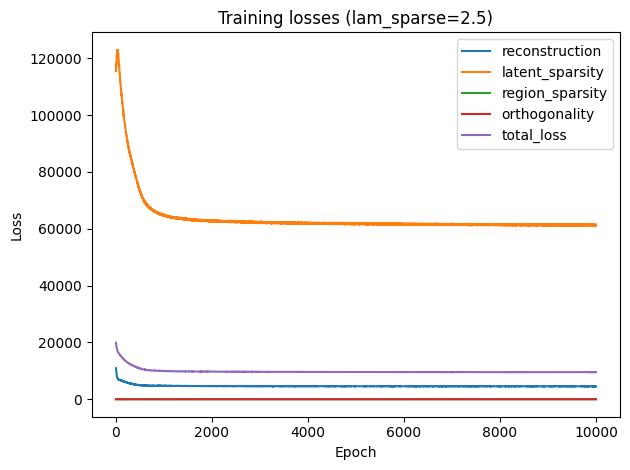

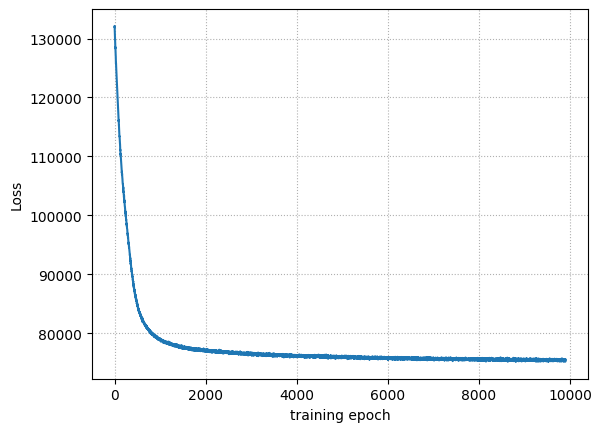

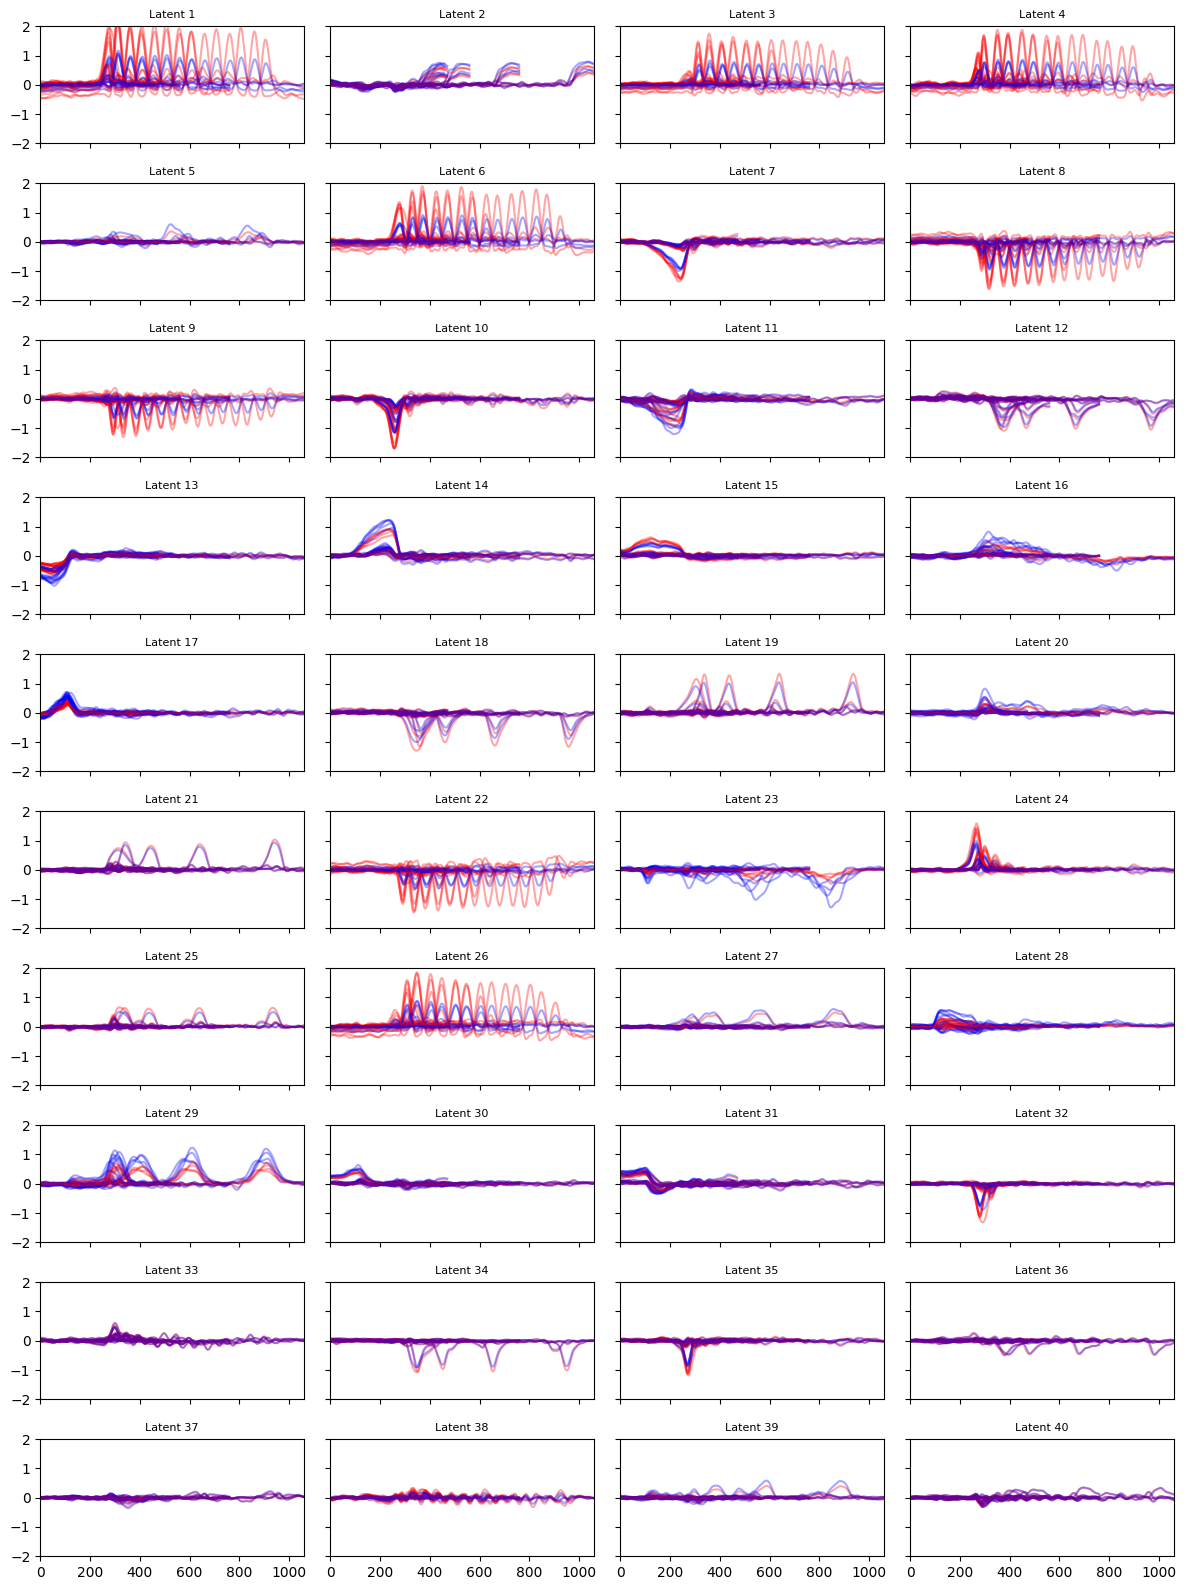

In [32]:
# run the cycling.py with linear encoder and decoder, lam_sparse=2.5
# load the model show the latents
msca = mSCA(n_components=40, n_epochs=10000, loss_func="Gaussian", lr=1e-3, filter_len=21, linear=True, region_weights=None, lam_sparse=None, lam_orthog=None, lam_region=None, batch_size=64, cd_rate=0.5, decoder_type="linear", decoder_hidden_size=40, decoder_activation="GeLU", device="cpu", cd_mode="both", post_hoc_epoch=1000)
model_fp = "./results/msca_cycling_LinearEncoder_LinearDecoder_Sparse2p5.pt"
loss_fp = "./results/losses_LinearEncoder_LinearDecoder_Sparse2p5.npz"
msca.load(model_fp, X)

losses = mSCA.load_losses(loss_fp)

# loss
# plt.figure(figsize=(9, 5))
for name, vals in losses.items():
    plt.plot(vals, label=name)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training losses (lam_sparse=2.5)")
plt.legend()
plt.tight_layout()
plt.show()


# Concatenate and sum the losses (reconstruction, latent sparsity, region, sparsity, and orthogonality)
loss = np.stack([v for v in losses.values()], axis=1).sum(axis=1)
plt.plot(loss[100:]); # Avoiding weirdness in early training
plt.grid(ls=":");
plt.ylabel("Loss");
plt.xlabel("training epoch")


# Latents
Z = msca.transform(X)
# fig, axs = plt.subplots(10, 4, figsize=(12, 8))
# for trial_num in range(4):
#     Z_m1_i = Z['M1'][trial_num]
#     Z_sma_i = Z['SMA'][trial_num]
#     for i in range(40):
#         axs[i // 4, i % 4].plot(Z_sma_i[:, i], c='b', alpha=0.5)
#         axs[i // 4, i % 4].plot(Z_m1_i[:, i], c='r', alpha=0.5)

n_components = 40
n_trials = min(20, len(Z['M1']), len(Z['SMA']))

# Global y-range across all plotted traces so every subplot uses the same scale
all_vals = []
for j in range(n_trials):
    all_vals.append(Z['M1'][j][:, :n_components].ravel())
    all_vals.append(Z['SMA'][j][:, :n_components].ravel())
all_vals = np.concatenate(all_vals)
ymin, ymax = np.min(all_vals), np.max(all_vals)
ymin, ymax = -2, 2
# Global x-range across all plotted traces
max_t = max(max(Z['M1'][j].shape[0], Z['SMA'][j].shape[0]) for j in range(n_trials))

fig, axs = plt.subplots(10, 4, figsize=(12, 16), sharex=True, sharey=True)
for i in range(n_components):
    ax = axs[i // 4, i % 4]
    for j in range(n_trials):
        ax.plot(Z['M1'][j][:, i], c='r', alpha=0.35)
        ax.plot(Z['SMA'][j][:, i], c='b', alpha=0.35)
    ax.set_xlim(0, max_t - 1)
    ax.set_ylim(ymin, ymax)
    ax.set_title(f'Latent {i + 1}', fontsize=8)

plt.tight_layout()
plt.show()

# With vs Without orthogonality: Seperating forward/backward cyclings across latents

Expectation:
- Without orthogonality: forward & backward entangled acorss latents
- With orthogonality: Some latents represent forward and some other latents represent backward

## Without orthogonality

## With orthogonality 
should be in the same latent 


In [53]:
from pathlib import Path

def load_data(dir_path, f):
    # Load in matlab file
    mat_file = io.loadmat(dir_path / f)

    # Grab data and mask
    data_array = mat_file["data"]
    mask = mat_file["mask"]

    # Grab the start and end indices for each trial
    start_idxs = mat_file["mask"]["firstTimeEachCond"][0][0].squeeze() - 1
    end_idxs = mat_file["mask"]["lastTimeEachCond"][0][0].squeeze()

    # Grab condition related things
    num_cycles = mask[0][0][1][start_idxs]
    direction = mask[0][0][2][start_idxs]
    position = mask[0][0][3][start_idxs]

    return data_array, mask, start_idxs, end_idxs, num_cycles, direction, position

# Load the data: number of cycles, direction, and position are added
candidate_dirs = [
    Path("./experiments/cycling/data"),
    Path("./data"),
    Path("data"),
]
fp = next((p for p in candidate_dirs if p.exists()), None)

m1_data, m1_mask, m1_start_idxs, m1_end_idxs, num_cycles, direction, position = load_data(
    fp, "Drake_interp_cycling_m1_rawRates.mat"
 )

sma_data, sma_mask, sma_start_idxs, sma_end_idxs, _, _, _ = load_data(
    fp, "Drake_interp_cycling_sma_rawRates.mat"
 )
print(fp)

data


Using region-weights = {'M1': 0.8285914749426891, 'SMA': 1.2608231468683218}
Using lam_sparse = 0.031020160209899346
Using lam_orthog = 23.021100351856102
Using lam_region = 0.0


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:315: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.output_layer.weight = torch.tensor(V_combined, dtype=torch.float32)  # type: ignore


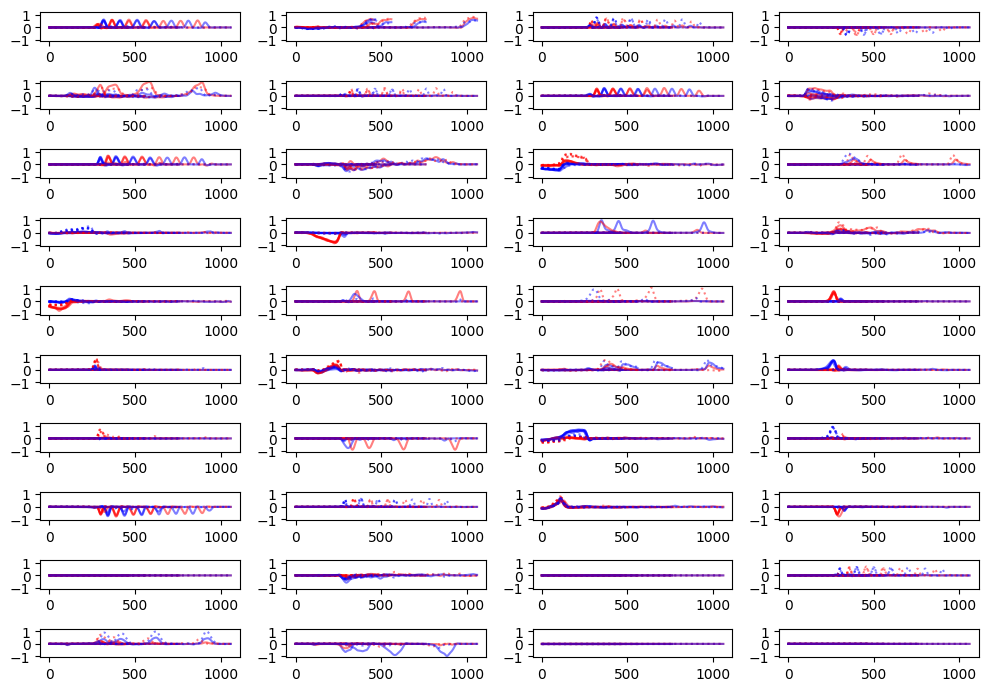

In [60]:
msca = mSCA(n_components=40, n_epochs=10000, loss_func="Gaussian", lr=1e-3, filter_len=21, linear=False, region_weights=None, lam_sparse=None, lam_orthog=None, lam_region=None, batch_size=64, cd_rate=0.5, decoder_type="nonlinear", decoder_hidden_size=40, decoder_activation="GeLU", device="cpu", cd_mode="both", post_hoc_epoch=1000)
msca.load("./results/msca_cycling_NonlinearEncoder_Sparse2p5.pt", X)

# Infer latents
Z = msca.transform(X)

# Settings for plotting
linestyles = {1: "-", -1: ":"}
start_pos = {0.0: "r", 0.5: "b"}

# Plot only SMA
fig, axs = plt.subplots(10, 4, figsize=(10, 7))

ymax = np.concatenate(Z["SMA"], axis=0).max()
ymin = np.concatenate(Z["SMA"], axis=0).min()

for i in range(n_trials):
    for j in range(40):
        axs[j // 4, j % 4].plot(
            Z["SMA"][i][:, j],
            c=start_pos[position[i].item()],
            ls=linestyles[direction[i].item()],
            alpha=0.5,
        )
        axs[j // 4, j % 4].set_ylim(ymin - 0.1, ymax + 0.1)

plt.tight_layout()
plt.show()